In [24]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np 
from torchvision import datasets, transforms
import time
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
transform = transforms.ToTensor()

# Tải tập huấn luyện (Train)
print("Đang tải tập Train...")
train_dataset = datasets.MNIST(root='../data',       # Thư mục lưu dữ liệu tải về
                               train=True,          # Lấy tập Train
                               download=True,       # Cho phép tự động tải từ Internet
                               transform=transform)

# Tải tập kiểm tra (Test)
print("Đang tải tập Test...")
test_dataset = datasets.MNIST(root='../data', 
                              train=False,         # Lấy tập Test
                              download=True, 
                              transform=transform)

print(f"Hoàn tất! Số lượng ảnh train: {len(train_dataset)}")
print(f"Hoàn tất! Số lượng ảnh test: {len(test_dataset)}")

Đang tải tập Train...


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.28MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 117kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.12MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.78MB/s]

Đang tải tập Test...
Hoàn tất! Số lượng ảnh train: 60000
Hoàn tất! Số lượng ảnh test: 10000


In [26]:
def preprocess(tensor_data):
    X_numpy = tensor_data.data.numpy()
    y_numpy = tensor_data.targets.numpy() 
    output_x = X_numpy.reshape(-1, 28 * 28) 
    output_y = y_numpy
    return output_x, output_y

In [27]:
kmeans = KMeans(n_clusters=10, random_state=42)

In [28]:
print("Đang huấn luyện KMeans...")
train_X, train_y = preprocess(train_dataset)
start_time = time.time()
kmeans.fit(train_X)
print(f"Huấn luyện xong! Thời gian chạy: {time.time() - start_time:.2f} giây")

Đang huấn luyện KMeans...
Huấn luyện xong! Thời gian chạy: 3.45 giây


In [29]:
def plot_centroids(centroids, n_rows=2, n_cols=5):
    """
    Hàm vẽ các tâm cụm (centroids) của MNIST.
    Mặc định vẽ 10 cụm chia thành 2 hàng, 5 cột.
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < len(centroids):
            # Lấy vector 784 chiều và biến lại thành ma trận ảnh 28x28
            image = centroids[i].reshape(28, 28)
            ax.imshow(image, cmap='gray')
            ax.set_title(f"Tâm cụm {i}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Đang hiển thị 10 tâm cụm học được từ KMeans...


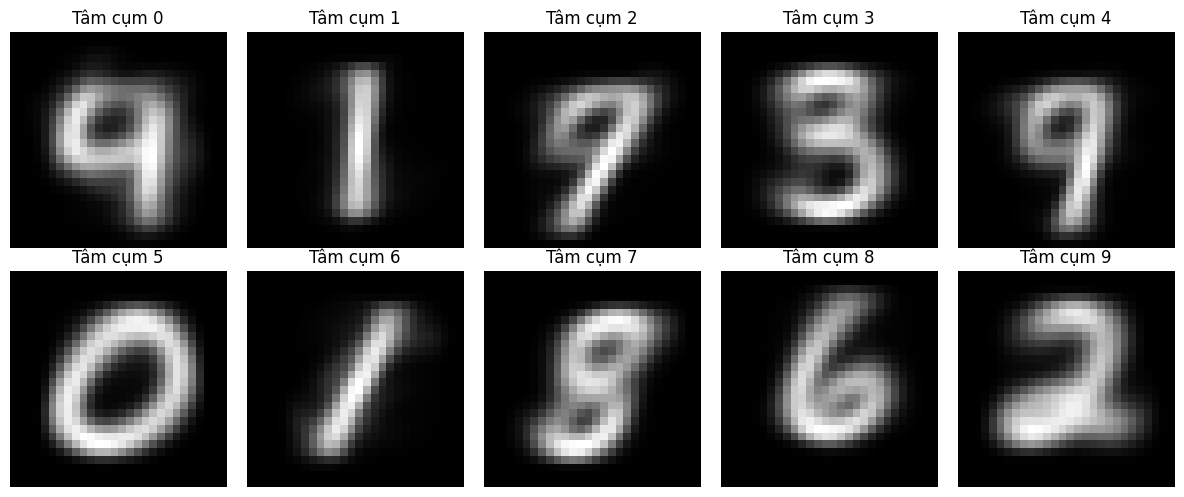

In [30]:
my_centroids = kmeans.cluster_centers_
print("Đang hiển thị 10 tâm cụm học được từ KMeans...")
plot_centroids(my_centroids, n_rows=2, n_cols=5)

--- BẮT ĐẦU PHẦN TEST ---
Đang tiền xử lý tập Test...
Đang dự đoán cụm cho tập Test...
Đang khớp nhãn cụm với chữ số thật...
Accuracy trên tập Test: 58.46%
Đang vẽ Confusion Matrix ...


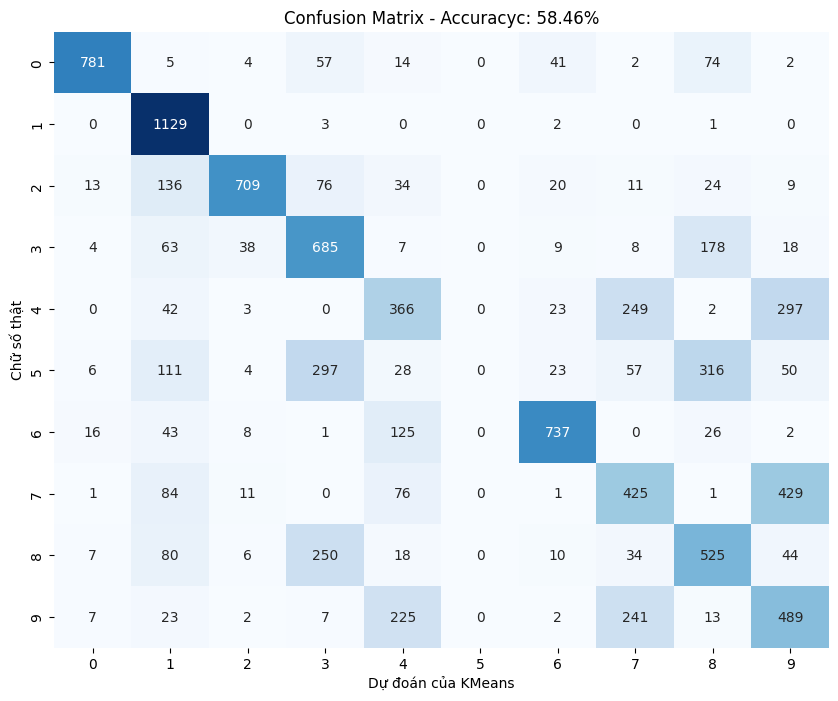

In [33]:
print("--- BẮT ĐẦU PHẦN TEST ---")
print("Đang tiền xử lý tập Test...")
test_X, test_y = preprocess(test_dataset)
print("Đang dự đoán cụm cho tập Test...")
test_clusters = kmeans.predict(test_X)
print("Đang khớp nhãn cụm với chữ số thật...")
train_clusters = kmeans.labels_
mapped_test_labels = np.zeros_like(test_clusters)

for i in range(10):
    # Tìm tất cả các ảnh trong tập Train thuộc cụm thứ i
    mask = (train_clusters == i)
    # Lấy nhãn thật (train_y) của các ảnh đó, tìm số xuất hiện nhiều nhất (mode)
    majority_label = mode(train_y[mask], keepdims=True)[0][0]
    # Gán số thật này cho các ảnh Test bị xếp vào cụm i
    mapped_test_labels[test_clusters == i] = majority_label

# 4. Tính Accuracy
acc = accuracy_score(test_y, mapped_test_labels)
print(f"Accuracy trên tập Test: {acc * 100:.2f}%")

# 5. Vẽ Confusion Matrix
print("Đang vẽ Confusion Matrix ...")
cm = confusion_matrix(test_y, mapped_test_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Dự đoán của KMeans")
plt.ylabel("Chữ số thật")
plt.title(f"Confusion Matrix - Accuracyc: {acc * 100:.2f}%")
plt.show()